# Cluster Visualization Notebook: PCA + UMAP

This notebook visualizes the saved V11 lifecycle clusters using PCA and UMAP.

It does **not** recluster developers. It reads the saved cluster membership table from DuckDB, joins cluster labels back to `dev_profile_final_v4`, and creates visualization samples for PCA/UMAP.

This version is aligned with the latest V11 methodology:
- `active`, `cooling`, and `at_risk` are modeled HDBSCAN strata.
- `dormant` is lightweight rule-based segmentation and is excluded from the main PCA/UMAP by default.
- `unactivated` is a pseudo-group and is excluded from the main PCA/UMAP by default.
- Column-name conflicts from merges are handled safely, so `stratum`, `cluster_key`, and `hdbscan_cluster` are normalized before sampling.

Recommended use:
1. Run the V11 clustering notebook first.
2. Confirm `dev_lifecycle_cluster_membership_v11_final` exists.
3. Run this visualization notebook.


In [1]:
# ============================================================
# 0. Imports and setup
# ============================================================

import gc
import warnings
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore", category=FutureWarning)

try:
    import umap
except ImportError:
    try:
        import umap.umap_ as umap
    except ImportError as exc:
        raise ImportError(
            "UMAP is not installed. Install it once with: pip install umap-learn"
        ) from exc

DB_PATH = globals().get("DB_PATH", "developer_project.duckdb")
PROFILE_TABLE = globals().get("PROFILE_TABLE", "dev_profile_final_v4")
ID_COL = globals().get("ID_COL", "developer_id")

OUTPUT_TABLE_PREFIX = "dev_lifecycle_cluster_membership_v11"
FINAL_TABLE = f"{OUTPUT_TABLE_PREFIX}_final"
PROFILE_SUMMARY_TABLE = f"{OUTPUT_TABLE_PREFIX}_profile_summary"
RUN_STATS_TABLE = "dev_lifecycle_cluster_run_stats_v11"

OUTPUT_DIR = Path("cluster_visualizations_v11")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42


In [2]:
# ============================================================
# 1. Connect to DuckDB and check whether clusters are saved
# ============================================================

con = duckdb.connect(DB_PATH)


def duckdb_table_exists(con, table_name):
    return con.execute(f"""
        SELECT COUNT(*)
        FROM information_schema.tables
        WHERE table_name = '{table_name}'
    """).fetchone()[0] > 0

required_tables = [PROFILE_TABLE, FINAL_TABLE]
optional_tables = [PROFILE_SUMMARY_TABLE]

status_rows = []
for table in required_tables + optional_tables:
    exists = duckdb_table_exists(con, table)
    n_rows = None
    if exists:
        n_rows = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    status_rows.append({"table_name": table, "exists": exists, "n_rows": n_rows})

status_df = pd.DataFrame(status_rows)
display(status_df)

missing_required = [r["table_name"] for r in status_rows[:len(required_tables)] if not r["exists"]]
if missing_required:
    raise ValueError(
        "Missing required saved cluster/profile tables: " + ", ".join(missing_required) +
        ". Run the V11 clustering notebook through the final-table rebuild step first."
    )

print("Clusters are saved and ready for visualization.")


,table_name,exists,n_rows
0,dev_profile_final_v4,True,9381508
1,dev_lifecycle_cluster_membership_v11_final,True,9381508
2,dev_lifecycle_cluster_membership_v11_profile_s...,True,26


Clusters are saved and ready for visualization.


In [3]:
# ============================================================
# 2. Load cluster membership and inspect counts
# ============================================================

membership_cols = con.execute(f"DESCRIBE {FINAL_TABLE}").df()["column_name"].tolist()
print("Final membership columns:", membership_cols)

required_membership_cols = [ID_COL, "stratum", "cluster_key", "hdbscan_cluster"]
missing_required_membership = [c for c in required_membership_cols if c not in membership_cols]
if missing_required_membership:
    raise ValueError(
        f"Missing required columns from {FINAL_TABLE}: {missing_required_membership}"
    )

optional_membership_cols = [
    "cluster_probability",
    "outlier_score",
    "adoption_direction",
    "proposed_business_label",
]
select_membership_cols = required_membership_cols + [
    c for c in optional_membership_cols if c in membership_cols
]

membership_df = con.execute(f"""
    SELECT {", ".join(select_membership_cols)}
    FROM {FINAL_TABLE}
""").df()

print("Membership rows:", len(membership_df))

cluster_counts = (
    membership_df
    .groupby(["stratum", "cluster_key"], dropna=False)
    .size()
    .reset_index(name="n_developers")
    .sort_values(["stratum", "n_developers"], ascending=[True, False])
)

display(cluster_counts)


Final membership columns: ['developer_id', 'stratum', 'hdbscan_cluster', 'cluster_probability', 'outlier_score', 'cluster_key', 'adoption_direction', 'proposed_business_label', 'interpretation_notes', 'recommended_action']
Membership rows: 9381508


,stratum,cluster_key,n_developers
5,active,active_5,155026
6,active,active_noise,105723
1,active,active_1,66683
3,active,active_3,29395
2,active,active_2,24653
4,active,active_4,18554
0,active,active_0,18015
7,at_risk,at_risk_0,436295
12,at_risk,at_risk_5,365945
9,at_risk,at_risk_2,210377


In [4]:
# ============================================================
# 3. Configuration for visualization sampling
# ============================================================

# PCA/UMAP can be expensive and unreadable on all 9M+ developers.
# The clustering itself is full-population; visualization uses a stratified sample.

MODELED_STRATA = ["active", "cooling", "at_risk"]
INCLUDE_NOISE = False
INCLUDE_DORMANT_AND_UNACTIVATED = False

# Recommended range: 3,000 to 10,000 per cluster.
# Increase if your machine can handle it.
VIZ_SAMPLE_PER_CLUSTER = 5000
MAX_TOTAL_VIZ_ROWS = 150000

# Latest V11 visualization features.
# These are intentionally shared behavioral interpretation features across active/cooling/at_risk.
VIZ_FEATURES = [
    "log_activity_count_0_30d",
    "log_activity_count_30_90d",
    "log_activity_count_90_180d",
    "unique_activity_types_0_30d",
    "unique_modalities_0_30d",
    "developer_effort_score",
    "weighted_recent_confidence_effort",
    "recent_build_flag",
    "log_build_count_0_30d",
    "build_share_lifetime",
    "high_effort_share_lifetime",
    "log_clipped_lifetime_activity_count_p99",
    "persona_entropy",
]

print("Modeled strata for PCA/UMAP:", MODELED_STRATA)
print("Include noise:", INCLUDE_NOISE)
print("Include dormant/unactivated:", INCLUDE_DORMANT_AND_UNACTIVATED)
print("Sample per cluster:", VIZ_SAMPLE_PER_CLUSTER)
print("Max total visualization rows:", MAX_TOTAL_VIZ_ROWS)


Modeled strata for PCA/UMAP: ['active', 'cooling', 'at_risk']
Include noise: False
Include dormant/unactivated: False
Sample per cluster: 5000
Max total visualization rows: 150000


In [5]:
# ============================================================
# 4. Load visualization features from profile table
# ============================================================

profile_cols = con.execute(f"DESCRIBE {PROFILE_TABLE}").df()["column_name"].tolist()
existing_viz_features = [c for c in VIZ_FEATURES if c in profile_cols]
missing_viz_features = [c for c in VIZ_FEATURES if c not in profile_cols]

print("Existing visualization features:", len(existing_viz_features))
print(existing_viz_features)

if missing_viz_features:
    print("Missing visualization features. They will be skipped:")
    for col in missing_viz_features:
        print("-", col)

if not existing_viz_features:
    raise ValueError("No visualization features were found in the profile table.")

select_cols = [ID_COL] + existing_viz_features
profile_feature_df = con.execute(f"""
    SELECT {", ".join(select_cols)}
    FROM {PROFILE_TABLE}
""").df()

print("Profile feature rows:", len(profile_feature_df))


Existing visualization features: 13
['log_activity_count_0_30d', 'log_activity_count_30_90d', 'log_activity_count_90_180d', 'unique_activity_types_0_30d', 'unique_modalities_0_30d', 'developer_effort_score', 'weighted_recent_confidence_effort', 'recent_build_flag', 'log_build_count_0_30d', 'build_share_lifetime', 'high_effort_share_lifetime', 'log_clipped_lifetime_activity_count_p99', 'persona_entropy']
Profile feature rows: 9381508


In [6]:
# ============================================================
# 5. Build visualization dataframe safely
# ============================================================

viz_df = membership_df.merge(
    profile_feature_df,
    on=ID_COL,
    how="left",
    suffixes=("_membership", "_profile"),
)

print("viz_df columns after merge:")
print(viz_df.columns.tolist())

# Normalize key columns in case any merge or prior notebook produced suffixes.
def ensure_column(df, target_col, candidates):
    if target_col in df.columns:
        return df
    for cand in candidates:
        if cand in df.columns:
            df[target_col] = df[cand]
            return df
    raise KeyError(
        f"Could not find `{target_col}`. Tried: {[target_col] + candidates}. "
        f"Available columns: {df.columns.tolist()}"
    )

viz_df = ensure_column(
    viz_df,
    "stratum",
    ["stratum_membership", "stratum_profile", "stratum_x", "stratum_y", "dormancy_segment", "lifecycle_stratum"],
)

viz_df = ensure_column(
    viz_df,
    "cluster_key",
    ["cluster_key_membership", "cluster_key_profile", "cluster_key_x", "cluster_key_y"],
)

if "hdbscan_cluster" not in viz_df.columns:
    for cand in ["hdbscan_cluster_membership", "hdbscan_cluster_profile", "hdbscan_cluster_x", "hdbscan_cluster_y"]:
        if cand in viz_df.columns:
            viz_df["hdbscan_cluster"] = viz_df[cand]
            break
if "hdbscan_cluster" not in viz_df.columns:
    viz_df["hdbscan_cluster"] = np.nan

# Coerce string columns to consistent text.
viz_df["stratum"] = viz_df["stratum"].astype(str).str.lower().str.strip()
viz_df["cluster_key"] = viz_df["cluster_key"].astype(str)

if INCLUDE_DORMANT_AND_UNACTIVATED:
    keep_strata = ["active", "cooling", "at_risk", "dormant", "unactivated"]
else:
    keep_strata = MODELED_STRATA

viz_df = viz_df[viz_df["stratum"].isin(keep_strata)].copy()

if not INCLUDE_NOISE:
    viz_df = viz_df[
        ~viz_df["cluster_key"].astype(str).str.contains("noise", na=False)
    ].copy()

# Drop rows with no usable feature values.
viz_df[existing_viz_features] = viz_df[existing_viz_features].replace([np.inf, -np.inf], np.nan)
viz_df = viz_df[viz_df[existing_viz_features].notna().any(axis=1)].copy()

print("Rows available for visualization before sampling:", len(viz_df))
display(
    viz_df.groupby(["stratum", "cluster_key"], dropna=False)
    .size()
    .reset_index(name="n_available")
    .sort_values(["stratum", "n_available"], ascending=[True, False])
)


viz_df columns after merge:
['developer_id', 'stratum', 'cluster_key', 'hdbscan_cluster', 'cluster_probability', 'outlier_score', 'adoption_direction', 'proposed_business_label', 'log_activity_count_0_30d', 'log_activity_count_30_90d', 'log_activity_count_90_180d', 'unique_activity_types_0_30d', 'unique_modalities_0_30d', 'developer_effort_score', 'weighted_recent_confidence_effort', 'recent_build_flag', 'log_build_count_0_30d', 'build_share_lifetime', 'high_effort_share_lifetime', 'log_clipped_lifetime_activity_count_p99', 'persona_entropy']
Rows available for visualization before sampling: 2070835


,stratum,cluster_key,n_available
5,active,active_5,155026
1,active,active_1,66683
3,active,active_3,29395
2,active,active_2,24653
4,active,active_4,18554
0,active,active_0,18015
6,at_risk,at_risk_0,436295
11,at_risk,at_risk_5,365945
8,at_risk,at_risk_2,210377
9,at_risk,at_risk_3,206907


In [7]:
# ============================================================
# 6. Stratified sample by cluster
# Robust version: avoids pandas groupby/apply column-loss issues
# ============================================================

# Re-normalize key columns here too, in case cells were run out of order.
def recover_column(df, target_col, candidates):
    if target_col in df.columns:
        return df
    for cand in candidates:
        if cand in df.columns:
            df[target_col] = df[cand]
            return df
    raise KeyError(
        f"Missing `{target_col}`. Tried candidates: {candidates}. "
        f"Available columns: {df.columns.tolist()}"
    )

viz_df = recover_column(
    viz_df,
    "stratum",
    [
        "stratum_membership",
        "stratum_profile",
        "stratum_x",
        "stratum_y",
        "dormancy_segment",
        "lifecycle_stratum",
    ],
)

viz_df = recover_column(
    viz_df,
    "cluster_key",
    [
        "cluster_key_membership",
        "cluster_key_profile",
        "cluster_key_x",
        "cluster_key_y",
    ],
)

if "hdbscan_cluster" not in viz_df.columns:
    for cand in [
        "hdbscan_cluster_membership",
        "hdbscan_cluster_profile",
        "hdbscan_cluster_x",
        "hdbscan_cluster_y",
    ]:
        if cand in viz_df.columns:
            viz_df["hdbscan_cluster"] = viz_df[cand]
            break

if "hdbscan_cluster" not in viz_df.columns:
    viz_df["hdbscan_cluster"] = np.nan

viz_df["stratum"] = viz_df["stratum"].astype(str).str.lower().str.strip()
viz_df["cluster_key"] = viz_df["cluster_key"].astype(str)

print("viz_df columns before sampling:")
print(viz_df.columns.tolist())
print("Rows before sampling:", len(viz_df))

required_for_sampling = ["stratum", "cluster_key"]
missing_for_sampling = [c for c in required_for_sampling if c not in viz_df.columns]
if missing_for_sampling:
    raise KeyError(f"Missing required sampling columns: {missing_for_sampling}")

if len(viz_df) == 0:
    raise ValueError("No rows available for visualization after filtering.")

# Avoid groupby.apply because some pandas versions / notebook states can drop columns unexpectedly.
sampled_parts = []
for (stratum_value, cluster_value), group in viz_df.groupby(
    ["stratum", "cluster_key"],
    dropna=False,
    sort=False,
):
    n_take = min(len(group), VIZ_SAMPLE_PER_CLUSTER)
    sampled_parts.append(group.sample(n=n_take, random_state=RANDOM_STATE))

viz_sample = pd.concat(sampled_parts, ignore_index=True) if sampled_parts else pd.DataFrame()

# Optional global cap. This keeps the notebook from becoming too slow.
if len(viz_sample) > MAX_TOTAL_VIZ_ROWS:
    viz_sample = (
        viz_sample
        .sample(n=MAX_TOTAL_VIZ_ROWS, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )

# Final safety check after sampling/capping.
viz_sample = recover_column(
    viz_sample,
    "stratum",
    [
        "stratum_membership",
        "stratum_profile",
        "stratum_x",
        "stratum_y",
        "dormancy_segment",
        "lifecycle_stratum",
    ],
)

viz_sample = recover_column(
    viz_sample,
    "cluster_key",
    [
        "cluster_key_membership",
        "cluster_key_profile",
        "cluster_key_x",
        "cluster_key_y",
    ],
)

if "hdbscan_cluster" not in viz_sample.columns:
    viz_sample["hdbscan_cluster"] = np.nan

print("Visualization sample rows:", len(viz_sample))
print("viz_sample columns after sampling:")
print(viz_sample.columns.tolist())

display(
    viz_sample
    .groupby(["stratum", "cluster_key"], dropna=False)
    .size()
    .reset_index(name="n_sampled")
    .sort_values(["stratum", "n_sampled"], ascending=[True, False])
)

sample_path = OUTPUT_DIR / "cluster_visualization_sample_v11.csv"
export_cols = [ID_COL, "stratum", "cluster_key", "hdbscan_cluster"] + existing_viz_features
export_cols = [c for c in export_cols if c in viz_sample.columns]
viz_sample[export_cols].to_csv(sample_path, index=False)
print("Saved visualization sample:", sample_path)



viz_df columns before sampling:
['developer_id', 'stratum', 'cluster_key', 'hdbscan_cluster', 'cluster_probability', 'outlier_score', 'adoption_direction', 'proposed_business_label', 'log_activity_count_0_30d', 'log_activity_count_30_90d', 'log_activity_count_90_180d', 'unique_activity_types_0_30d', 'unique_modalities_0_30d', 'developer_effort_score', 'weighted_recent_confidence_effort', 'recent_build_flag', 'log_build_count_0_30d', 'build_share_lifetime', 'high_effort_share_lifetime', 'log_clipped_lifetime_activity_count_p99', 'persona_entropy']
Rows before sampling: 2070835
Visualization sample rows: 95000
viz_sample columns after sampling:
['developer_id', 'stratum', 'cluster_key', 'hdbscan_cluster', 'cluster_probability', 'outlier_score', 'adoption_direction', 'proposed_business_label', 'log_activity_count_0_30d', 'log_activity_count_30_90d', 'log_activity_count_90_180d', 'unique_activity_types_0_30d', 'unique_modalities_0_30d', 'developer_effort_score', 'weighted_recent_confidence

,stratum,cluster_key,n_sampled
0,active,active_0,5000
1,active,active_1,5000
2,active,active_2,5000
3,active,active_3,5000
4,active,active_4,5000
5,active,active_5,5000
6,at_risk,at_risk_0,5000
7,at_risk,at_risk_1,5000
8,at_risk,at_risk_2,5000
9,at_risk,at_risk_3,5000


Saved visualization sample: cluster_visualizations_v11/cluster_visualization_sample_v11.csv


In [8]:
# ============================================================
# 7. Preprocess feature matrix
# ============================================================

X_raw = viz_sample[existing_viz_features].replace([np.inf, -np.inf], np.nan)

prep = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

X = prep.fit_transform(X_raw).astype("float32")

# Drop zero-variance columns after preprocessing.
keep_mask = np.nanvar(X, axis=0) > 1e-12
kept_features = [f for f, keep in zip(existing_viz_features, keep_mask) if keep]
dropped_features = [f for f, keep in zip(existing_viz_features, keep_mask) if not keep]
X = X[:, keep_mask]

if X.shape[1] == 0:
    raise ValueError("All visualization features became zero-variance after preprocessing.")

print("Final feature matrix shape:", X.shape)
print("Kept features:", kept_features)
if dropped_features:
    print("Dropped zero-variance features:", dropped_features)


Final feature matrix shape: (95000, 13)
Kept features: ['log_activity_count_0_30d', 'log_activity_count_30_90d', 'log_activity_count_90_180d', 'unique_activity_types_0_30d', 'unique_modalities_0_30d', 'developer_effort_score', 'weighted_recent_confidence_effort', 'recent_build_flag', 'log_build_count_0_30d', 'build_share_lifetime', 'high_effort_share_lifetime', 'log_clipped_lifetime_activity_count_p99', 'persona_entropy']


In [9]:
# ============================================================
# 8. PCA projection
# ============================================================

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_xy = pca.fit_transform(X)

viz_sample["pca_1"] = pca_xy[:, 0]
viz_sample["pca_2"] = pca_xy[:, 1]

print("PCA explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

pca_path = OUTPUT_DIR / "cluster_pca_coordinates_v11.csv"
viz_sample[[ID_COL, "stratum", "cluster_key", "pca_1", "pca_2"]].to_csv(pca_path, index=False)
print("Saved PCA coordinates:", pca_path)


PCA explained variance ratio: [0.44419754 0.2586726 ]
Total explained variance: 0.70287013
Saved PCA coordinates: cluster_visualizations_v11/cluster_pca_coordinates_v11.csv


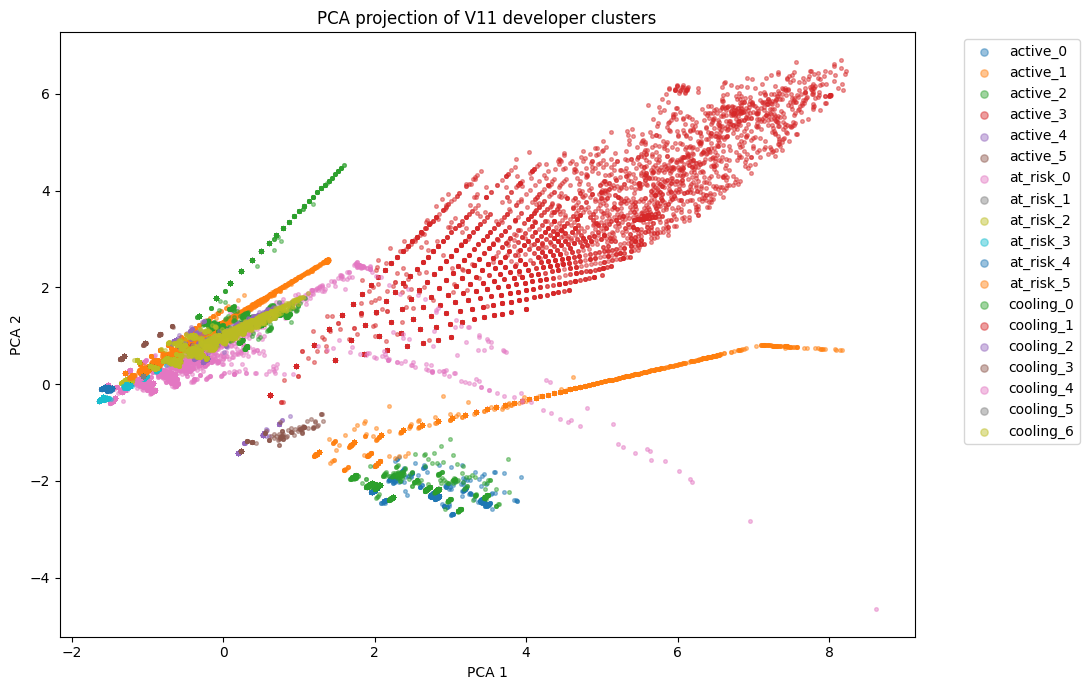

Saved: cluster_visualizations_v11/pca_by_cluster_v11.png


In [10]:
# ============================================================
# 9A. PCA colored by cluster
# ============================================================

plt.figure(figsize=(11, 7))

for cluster_key, g in viz_sample.groupby("cluster_key"):
    plt.scatter(
        g["pca_1"],
        g["pca_2"],
        s=7,
        alpha=0.45,
        label=cluster_key,
    )

plt.title("PCA projection of V11 developer clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

pca_cluster_png = OUTPUT_DIR / "pca_by_cluster_v11.png"
plt.savefig(pca_cluster_png, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", pca_cluster_png)


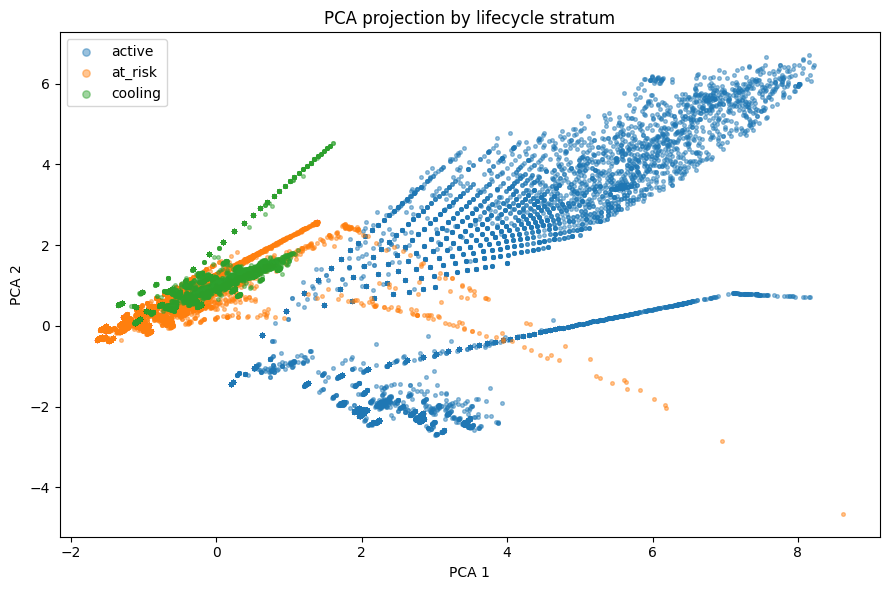

Saved: cluster_visualizations_v11/pca_by_stratum_v11.png


In [11]:
# ============================================================
# 9B. PCA colored by lifecycle stratum
# ============================================================

plt.figure(figsize=(9, 6))

for stratum, g in viz_sample.groupby("stratum"):
    plt.scatter(
        g["pca_1"],
        g["pca_2"],
        s=7,
        alpha=0.45,
        label=stratum,
    )

plt.title("PCA projection by lifecycle stratum")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(markerscale=2)
plt.tight_layout()

pca_stratum_png = OUTPUT_DIR / "pca_by_stratum_v11.png"
plt.savefig(pca_stratum_png, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", pca_stratum_png)


In [12]:
# ============================================================
# 10. UMAP projection
# ============================================================

# UMAP is nonlinear and better for local cluster structure than PCA.
# Runtime depends heavily on the number of sampled rows.

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.10,
    metric="euclidean",
    random_state=RANDOM_STATE,
    low_memory=True,
)

umap_xy = umap_model.fit_transform(X)

viz_sample["umap_1"] = umap_xy[:, 0]
viz_sample["umap_2"] = umap_xy[:, 1]

umap_path = OUTPUT_DIR / "cluster_umap_coordinates_v11.csv"
viz_sample[[ID_COL, "stratum", "cluster_key", "umap_1", "umap_2"]].to_csv(umap_path, index=False)
print("Saved UMAP coordinates:", umap_path)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved UMAP coordinates: cluster_visualizations_v11/cluster_umap_coordinates_v11.csv


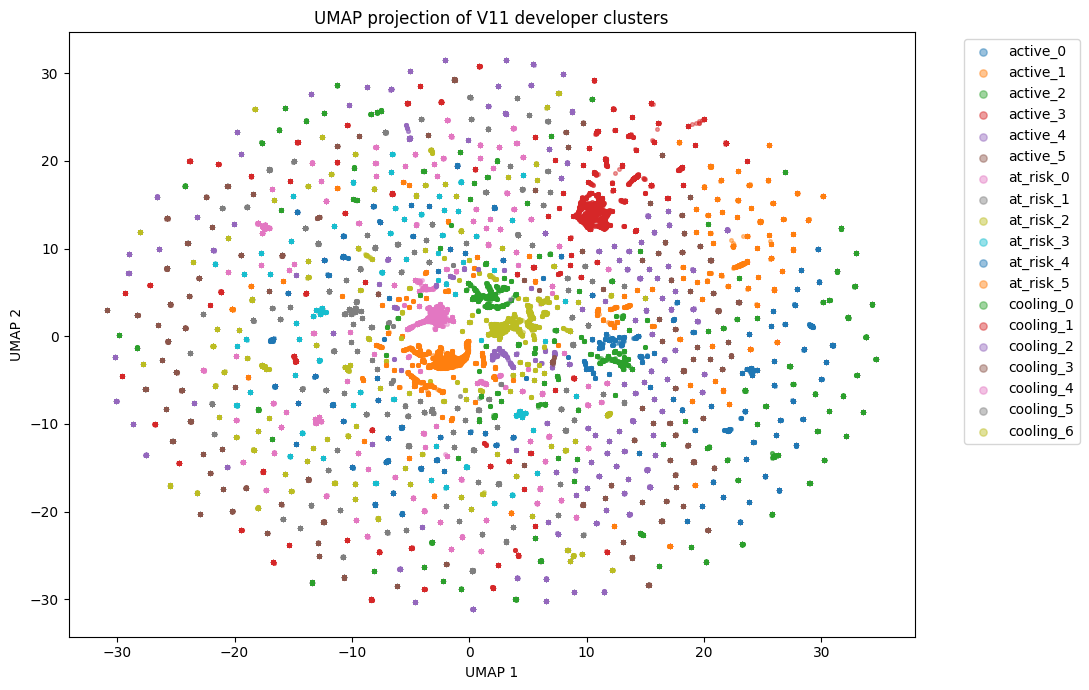

Saved: cluster_visualizations_v11/umap_by_cluster_v11.png


In [13]:
# ============================================================
# 11A. UMAP colored by cluster
# ============================================================

plt.figure(figsize=(11, 7))

for cluster_key, g in viz_sample.groupby("cluster_key"):
    plt.scatter(
        g["umap_1"],
        g["umap_2"],
        s=7,
        alpha=0.45,
        label=cluster_key,
    )

plt.title("UMAP projection of V11 developer clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

umap_cluster_png = OUTPUT_DIR / "umap_by_cluster_v11.png"
plt.savefig(umap_cluster_png, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", umap_cluster_png)


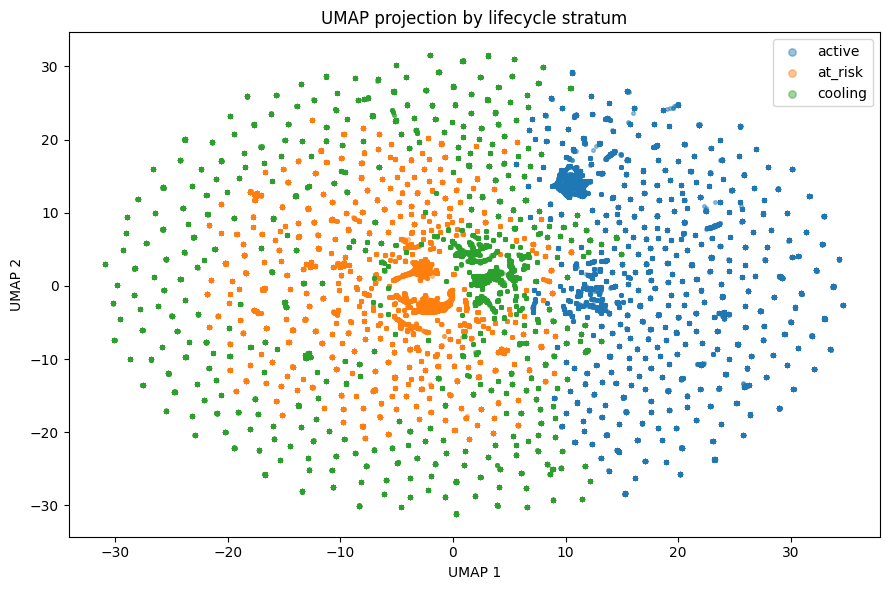

Saved: cluster_visualizations_v11/umap_by_stratum_v11.png


In [14]:
# ============================================================
# 11B. UMAP colored by lifecycle stratum
# ============================================================

plt.figure(figsize=(9, 6))

for stratum, g in viz_sample.groupby("stratum"):
    plt.scatter(
        g["umap_1"],
        g["umap_2"],
        s=7,
        alpha=0.45,
        label=stratum,
    )

plt.title("UMAP projection by lifecycle stratum")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(markerscale=2)
plt.tight_layout()

umap_stratum_png = OUTPUT_DIR / "umap_by_stratum_v11.png"
plt.savefig(umap_stratum_png, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", umap_stratum_png)


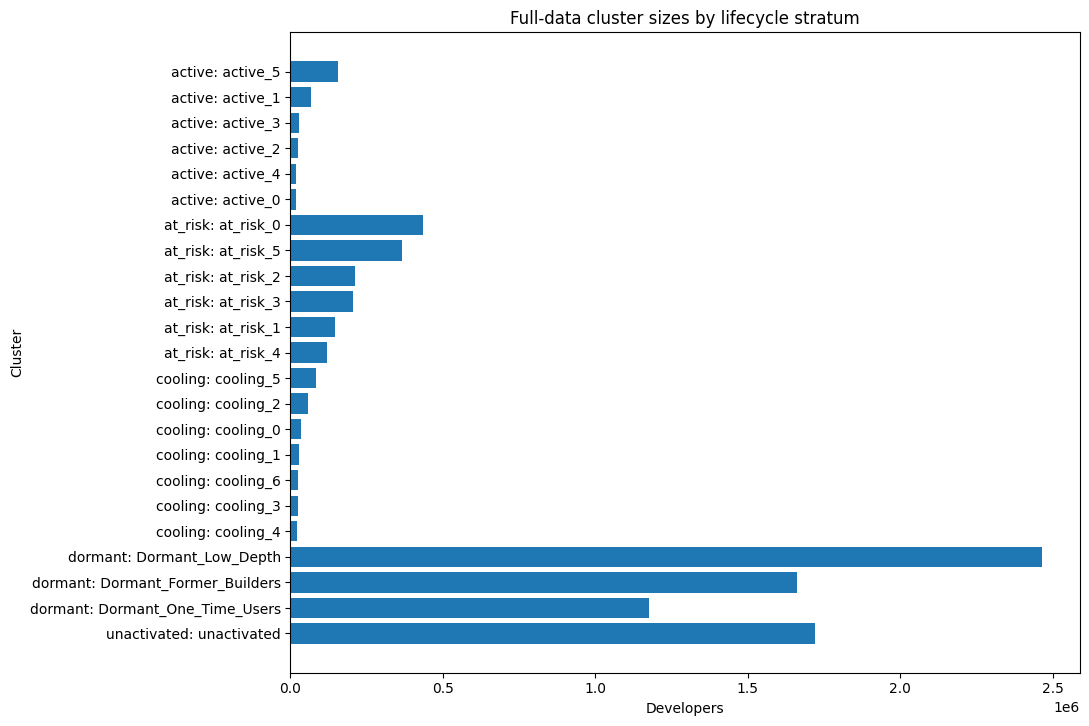

Saved: cluster_visualizations_v11/full_data_cluster_sizes_v11.png


In [15]:
# ============================================================
# 12. Cluster size chart from full data
# ============================================================

cluster_size_plot = (
    membership_df
    .groupby(["stratum", "cluster_key"])
    .size()
    .reset_index(name="n_developers")
)

cluster_size_plot = cluster_size_plot[
    ~cluster_size_plot["cluster_key"].str.contains("noise", na=False)
].copy()

cluster_size_plot = cluster_size_plot.sort_values(
    ["stratum", "n_developers"],
    ascending=[True, False]
)

cluster_size_plot["label"] = (
    cluster_size_plot["stratum"] + ": " + cluster_size_plot["cluster_key"]
)

plt.figure(figsize=(11, max(5, 0.32 * len(cluster_size_plot))))
plt.barh(cluster_size_plot["label"], cluster_size_plot["n_developers"])
plt.title("Full-data cluster sizes by lifecycle stratum")
plt.xlabel("Developers")
plt.ylabel("Cluster")
plt.gca().invert_yaxis()
plt.tight_layout()

cluster_size_png = OUTPUT_DIR / "full_data_cluster_sizes_v11.png"
plt.savefig(cluster_size_png, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", cluster_size_png)


In [16]:
# ============================================================
# 13. Optional: cluster centroids projected into PCA space
# ============================================================

centroids = (
    viz_sample
    .groupby(["stratum", "cluster_key"], as_index=False)
    .agg(
        pca_1=("pca_1", "mean"),
        pca_2=("pca_2", "mean"),
        umap_1=("umap_1", "mean"),
        umap_2=("umap_2", "mean"),
        n_sampled=(ID_COL, "count"),
    )
)

display(centroids)

centroid_path = OUTPUT_DIR / "cluster_visualization_centroids_v11.csv"
centroids.to_csv(centroid_path, index=False)
print("Saved centroids:", centroid_path)


,stratum,cluster_key,pca_1,pca_2,umap_1,umap_2,n_sampled
0,active,active_0,2.221307,-2.201587,22.686909,-5.908482,5000
1,active,active_1,2.682924,-0.855086,21.723248,6.823071,5000
2,active,active_2,2.182316,-2.142032,24.090666,-5.557607,5000
3,active,active_3,3.771634,2.640932,12.757516,17.413445,5000
4,active,active_4,0.212662,-1.414937,14.418492,-2.991782,5000
5,active,active_5,0.245554,-1.377859,16.860191,-3.208541,5000
6,at_risk,at_risk_0,-0.766420,0.155369,-5.702323,2.513997,5000
7,at_risk,at_risk_1,-1.250967,0.069519,-5.549192,-0.852839,5000
8,at_risk,at_risk_2,-1.231107,0.064991,-9.467401,-1.564235,5000
9,at_risk,at_risk_3,-1.545087,-0.251684,-6.503004,1.135315,5000


Saved centroids: cluster_visualizations_v11/cluster_visualization_centroids_v11.csv


In [17]:
# ============================================================
# 14. Interpretation notes
# ============================================================

print("""
How to read these visuals:

1. PCA shows broad linear separation in the feature space.
2. UMAP shows local/nonlinear separation and is usually better for presentation.
3. Cluster size charts are full-data charts, not sampled charts.
4. PCA/UMAP are diagnostics, not proof that the clusters are correct.
5. The production output remains dev_lifecycle_cluster_membership_v11_final.
6. The main PCA/UMAP intentionally focuses on active, cooling, and at_risk because those are the modeled HDBSCAN strata.
7. Dormant and unactivated are excluded by default because they are rule-based or pseudo-groups, not behavioral HDBSCAN clusters.
""")

con.close()
print("DuckDB connection closed.")



How to read these visuals:

1. PCA shows broad linear separation in the feature space.
2. UMAP shows local/nonlinear separation and is usually better for presentation.
3. Cluster size charts are full-data charts, not sampled charts.
4. PCA/UMAP are diagnostics, not proof that the clusters are correct.
5. The production output remains dev_lifecycle_cluster_membership_v11_final.
6. The main PCA/UMAP intentionally focuses on active, cooling, and at_risk because those are the modeled HDBSCAN strata.
7. Dormant and unactivated are excluded by default because they are rule-based or pseudo-groups, not behavioral HDBSCAN clusters.

DuckDB connection closed.
